# Análisis exploratorio — datos scrapeados

Exploración del dataset de titulares uruguayos: volumen, fuentes, etiquetas GPT y distribución temporal.

**Fuente:** export CSV más reciente en `data/exports/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "config.yml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

from mindful_news.training.data import latest_export_csv, load_labeled_headlines, make_temporal_splits

export_path = latest_export_csv()
print("Export:", export_path)
df = load_labeled_headlines(str(export_path) if export_path else None)
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df["scraped_at"] = pd.to_datetime(df["scraped_at"], errors="coerce")
df["titulo_len"] = df["titulo"].str.len()
df.head(3)


c:\Users\arihs\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Export: C:\Users\arihs\Code\mlprod-obligatorio\data\exports\headlines_20260605.csv


,id,external_id,titulo,url,thumbnail_url,medio,seccion,fecha,scraped_at,source_run,tema,carga,classified_at,split_date,titulo_len
0,14385,6046315,Insólito: científicos encuentran levadura en l...,https://www.elobservador.com.uy/espana/sucede/...,https://media.elobservador.com.uy/p/01765afc08...,El Observador,espana,1991-09-19 00:00:00,2026-06-05 00:44:02,bulk,cultura,baja,2026-06-05 01:06:27,1991-09-19 00:00:00,108
1,8531,https://www.elpais.com.uy/informacion/politica...,"ASSE, violencia en el fútbol y pasaportes: con...",https://www.elpais.com.uy/informacion/politica...,https://imgs.elpais.com.uy/dims4/default/e8511...,El País,informacion,2025-07-10 16:13:42,2026-06-05 00:19:59,bulk,politica,media,2026-06-05 00:54:16,2025-07-10 16:13:42,106
2,8530,https://www.elpais.com.uy/informacion/politica...,Asumió Legnani como intendente de Canelones: s...,https://www.elpais.com.uy/informacion/politica...,https://imgs.elpais.com.uy/dims4/default/44eb9...,El País,informacion,2025-07-10 16:40:50,2026-06-05 00:19:59,bulk,politica,baja,2026-06-05 00:54:16,2025-07-10 16:40:50,110


In [2]:
summary = {
    "filas": len(df),
    "medios": df["medio"].nunique(),
    "temas": df["tema"].nunique(),
    "cargas": df["carga"].nunique(),
    "desde": df["split_date"].min(),
    "hasta": df["split_date"].max(),
}
pd.Series(summary)


filas                   12005
medios                      4
temas                      10
cargas                      3
desde     1991-09-19 00:00:00
hasta     2026-06-05 00:19:59
dtype: object

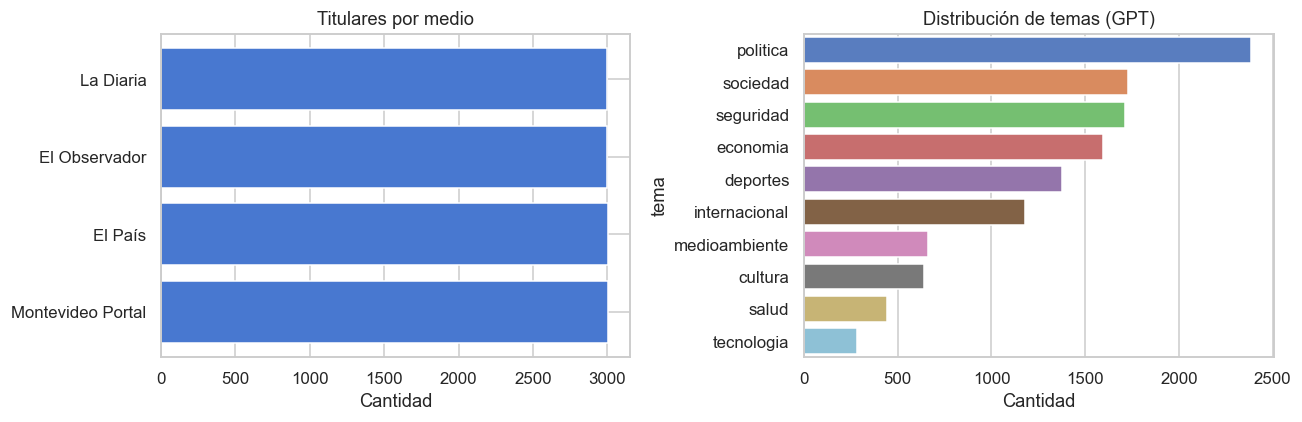

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

medio_counts = df["medio"].value_counts()
axes[0].barh(medio_counts.index, medio_counts.values, color=sns.color_palette()[0])
axes[0].set_title("Titulares por medio")
axes[0].set_xlabel("Cantidad")

tema_counts = df["tema"].value_counts()
sns.barplot(x=tema_counts.values, y=tema_counts.index, ax=axes[1], orient="h")
axes[1].set_title("Distribución de temas (GPT)")
axes[1].set_xlabel("Cantidad")
plt.tight_layout()
plt.show()


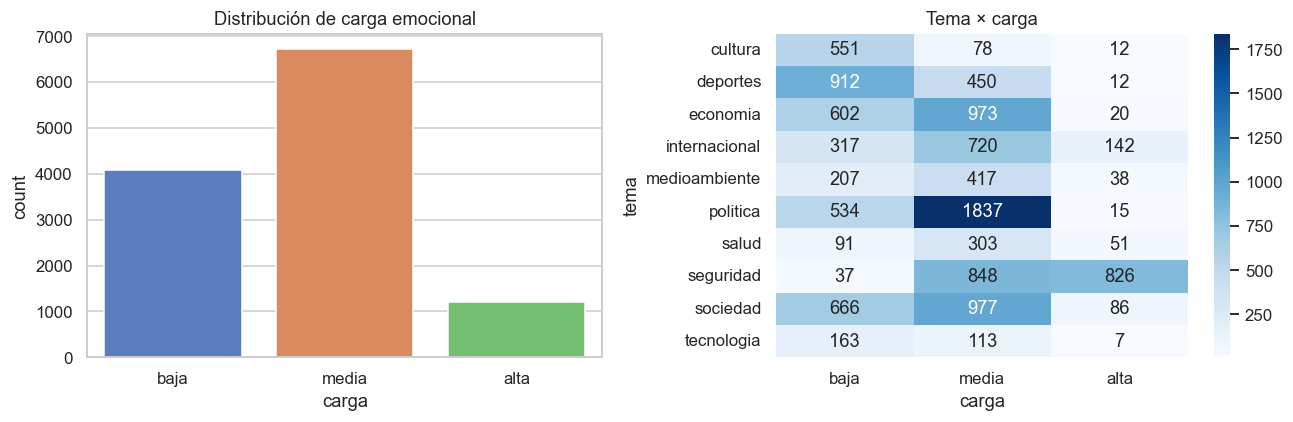

In [4]:
order = ["baja", "media", "alta"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="carga", order=order, ax=axes[0])
axes[0].set_title("Distribución de carga emocional")

ct = pd.crosstab(df["tema"], df["carga"]).loc[:, order]
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Tema × carga")
plt.tight_layout()
plt.show()


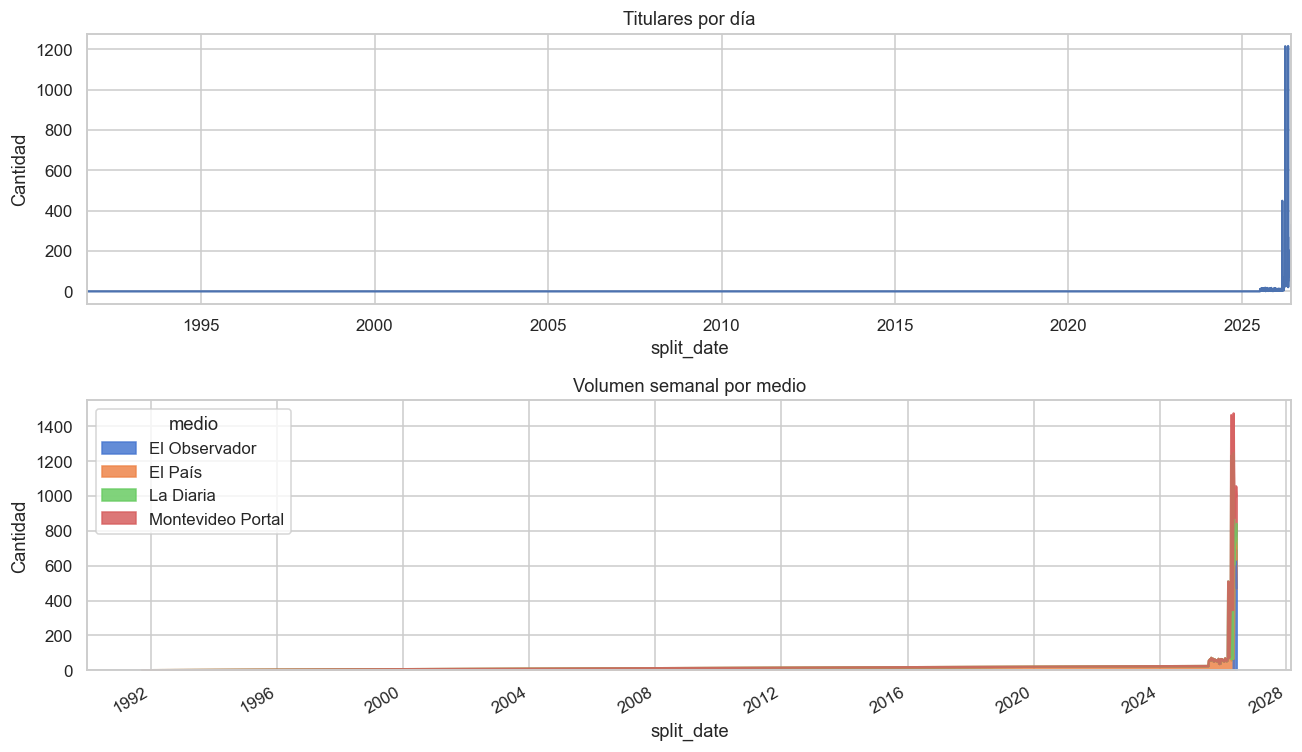

In [5]:
daily = df.set_index("split_date").resample("D").size()
weekly_medio = df.groupby([pd.Grouper(key="split_date", freq="W"), "medio"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
daily.plot(ax=axes[0], color="#4C72B0")
axes[0].set_title("Titulares por día")
axes[0].set_ylabel("Cantidad")

weekly_medio.plot(kind="area", stacked=True, ax=axes[1], alpha=0.85)
axes[1].set_title("Volumen semanal por medio")
axes[1].set_ylabel("Cantidad")
plt.tight_layout()
plt.show()


c:\Users\arihs\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


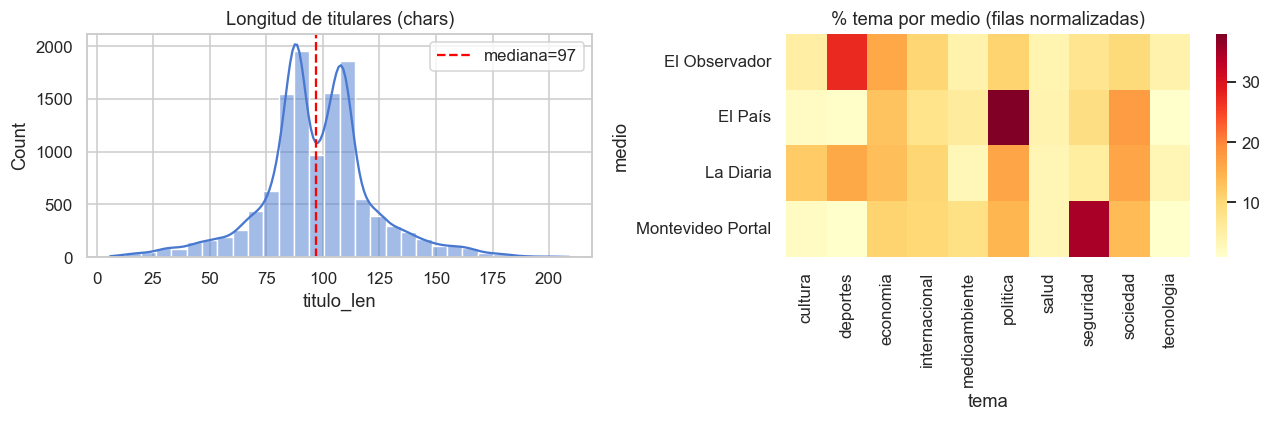

Longitud min/med/max: 6 97.0 209


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["titulo_len"], bins=30, kde=True, ax=axes[0])
med = df["titulo_len"].median()
axes[0].axvline(med, ls="--", c="red", label=f"mediana={med:.0f}")
axes[0].set_title("Longitud de titulares (chars)")
axes[0].legend()

tema_medio = pd.crosstab(df["medio"], df["tema"], normalize="index") * 100
sns.heatmap(tema_medio, cmap="YlOrRd", ax=axes[1])
axes[1].set_title("% tema por medio (filas normalizadas)")
plt.tight_layout()
plt.show()

print("Longitud min/med/max:", df["titulo_len"].min(), med, df["titulo_len"].max())


In [7]:
splits = make_temporal_splits(df)
split_sizes = pd.Series({k: len(v) for k, v in splits.items()})
display(split_sizes)

print("Rango temporal por split:")
for name, part in splits.items():
    start = part["split_date"].min()
    end = part["split_date"].max()
    print(f"  {name:5s}: {start} -> {end} ({len(part)} filas)")


train    8403
val      1801
test     1801
dtype: int64

Rango temporal por split:
  train: 1991-09-19 00:00:00 -> 2026-05-13 14:21:00 (8403 filas)
  val  : 2026-05-13 14:26:00 -> 2026-05-26 12:50:00 (1801 filas)
  test : 2026-05-26 12:52:00 -> 2026-06-05 00:19:59 (1801 filas)


In [8]:
for label_col in ["tema", "carga"]:
    print(f"\n=== Ejemplos por {label_col} ===")
    for label, group in df.groupby(label_col):
        sample = group.sample(min(2, len(group)), random_state=42)
        print(f"\n-- {label} --")
        for _, row in sample.iterrows():
            print(f"  [{row['medio']}] {row['titulo'][:100]}")



=== Ejemplos por tema ===

-- cultura --
  [Montevideo Portal] Poco menos de la mitad de los uruguayos no leyó un libro en todo el 2025, según encuesta
  [La Diaria] la carpa de espectaculos del parque batlle se muda al parque roosevelt

-- deportes --
  [La Diaria] matematicamente tenemos chance la celeste femenina y sus posibilidades
  [El Observador] FIFA cambió el reglamento del Mundial 2026 para permitir que jugadores lleguen sin suspensiones al t

-- economia --
  [Montevideo Portal] Adeom aprueba convenio con la IM: suba salarial de 1,5 % y plan de ascensos hasta 2029
  [El Observador] Cómo se gestó la descomunal deuda de Venezuela y la riesgosa renegociación que impulsa Delcy Rodrígu

-- internacional --
  [El País] Pese a ser excluido de cumbre en Miami, gobierno busca mantener un vínculo "fuerte y fluido" con Est
  [El País] Legisladores argentinos piden a Orsi que instale una "mesa de diálogo" por planta de HIF Global en P

-- medioambiente --
  [Montevideo Portal] Organiza